# Sierpiński Gasket Using Binary Addresses

This notebook implements and analyses the Sierpiński gasket using
binary coordinate addresses and PyTorch tensor operations.

The project demonstrates tensor parallelism, visualisation,
performance comparison, and fractal-dimension analysis.

In [2]:
import torch
import matplotlib.pyplot as plt

print("PyTorch version:", torch.__version__)

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Selected device:", device)

PyTorch version: 2.13.0
Selected device: mps


## Binary-address rule

The Sierpiński gasket can be revealed through the parity pattern of
Pascal's triangle. A cell at row `n` and position `k` is odd when:

\[
k \;\&\; (n-k) = 0
\]

Here, `&` denotes the bitwise AND operation. This test avoids computing
the potentially very large binomial coefficient directly.

In [3]:
# Number of rows in Pascal's triangle
size = 256

# Integer addresses created directly on the selected device
indices = torch.arange(
    size,
    dtype=torch.int32,
    device=device
)

# Rows have shape (256, 1); columns have shape (1, 256)
rows = indices[:, None]
columns = indices[None, :]

# Only positions inside Pascal's triangular region are valid
valid_region = columns <= rows

# A Pascal cell is odd when no binary 1-bits overlap
binary_test = torch.bitwise_and(
    columns,
    rows - columns
) == 0

gasket = valid_region & binary_test

print("Gasket shape:", gasket.shape)
print("Gasket data type:", gasket.dtype)
print("Gasket device:", gasket.device)
print("Number of active points:", gasket.sum().item())

Gasket shape: torch.Size([256, 256])
Gasket data type: torch.bool
Gasket device: mps:0
Number of active points: 6561


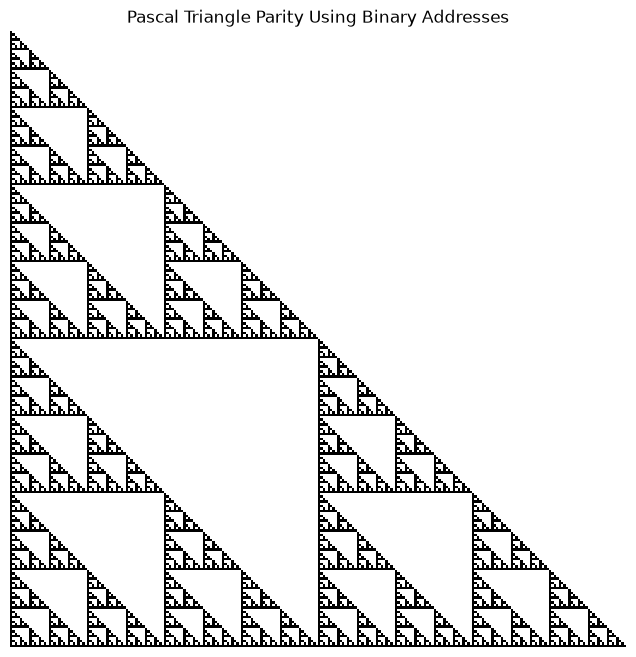

In [4]:
plt.figure(figsize=(8, 8))

plt.imshow(
    gasket.cpu().numpy(),
    cmap="binary",
    interpolation="nearest"
)

plt.title("Pascal Triangle Parity Using Binary Addresses")
plt.axis("off")
plt.show()

## Centred Sierpiński gasket

The binary-address calculation produces a left-aligned Pascal triangle.
For visualisation, each active cell at row `n` and position `k` is
mapped to the centred horizontal coordinate

\[
x = (N - 1 - n) + 2k
\]

This changes only the display coordinates. The membership of every
point is still determined by the binary-address test.

In [5]:
# Find the addresses of all active points
active_rows, active_columns = torch.where(gasket)

# Create a wider canvas for a centred triangle
centred_gasket = torch.zeros(
    (size, 2 * size - 1),
    dtype=torch.bool,
    device=device
)

# Convert Pascal addresses into centred display coordinates
centred_columns = (
    size - 1 - active_rows
    + 2 * active_columns
)

# Place the active points on the centred canvas
centred_gasket[
    active_rows,
    centred_columns
] = True

print("Centred image shape:", centred_gasket.shape)
print("Centred image device:", centred_gasket.device)
print("Number of active points:", centred_gasket.sum().item())

Centred image shape: torch.Size([256, 511])
Centred image device: mps:0
Number of active points: 6561


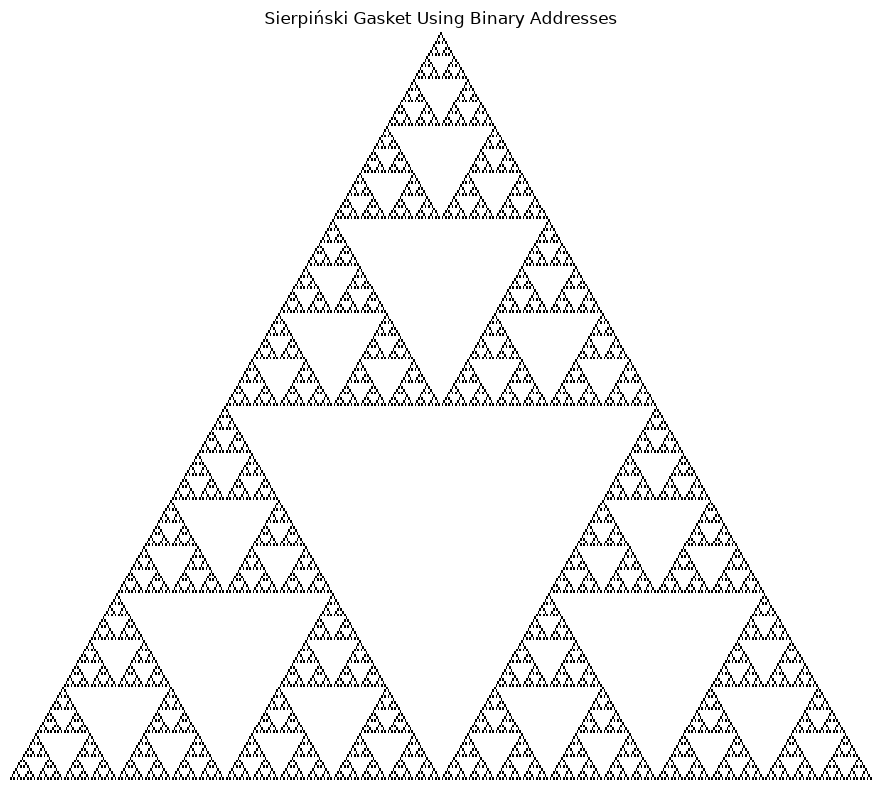

In [6]:
plt.figure(figsize=(10, 8))

plt.imshow(
    centred_gasket.cpu().numpy(),
    cmap="binary",
    interpolation="nearest",
    aspect=3 ** 0.5
)

plt.title("Sierpiński Gasket Using Binary Addresses")
plt.axis("off")
plt.tight_layout()
plt.show()

## Reusable PyTorch implementation

The generation process is placed inside a function so that different
image resolutions and computational devices can be tested consistently.
All pixel addresses are evaluated simultaneously using PyTorch tensor
operations, without a Python loop over individual pixels.

In [7]:
def generate_sierpinski(size, computation_device):
    """
    Generate raw and centred Sierpiński gasket masks using
    the binary-address test.

    Parameters
    ----------
    size : int
        Number of rows in Pascal's triangle.
    computation_device : torch.device
        Device used for tensor calculations.

    Returns
    -------
    raw_gasket : torch.Tensor
        Left-aligned Pascal parity mask.
    centred_gasket : torch.Tensor
        Centred visualisation mask.
    """
    if not isinstance(size, int) or size < 2:
        raise ValueError("size must be an integer greater than 1")

    indices = torch.arange(
        size,
        dtype=torch.int32,
        device=computation_device
    )

    rows = indices[:, None]
    columns = indices[None, :]

    valid_region = columns <= rows

    binary_test = torch.bitwise_and(
        columns,
        rows - columns
    ) == 0

    raw_gasket = valid_region & binary_test

    active_rows, active_columns = torch.where(raw_gasket)

    centred_gasket = torch.zeros(
        (size, 2 * size - 1),
        dtype=torch.bool,
        device=computation_device
    )

    centred_columns = (
        size - 1 - active_rows
        + 2 * active_columns
    )

    centred_gasket[
        active_rows,
        centred_columns
    ] = True

    return raw_gasket, centred_gasket

In [8]:
high_resolution_size = 1024

raw_high_res, centred_high_res = generate_sierpinski(
    high_resolution_size,
    device
)

print("Raw shape:", raw_high_res.shape)
print("Centred shape:", centred_high_res.shape)
print("Device:", centred_high_res.device)
print("Active points:", centred_high_res.sum().item())

Raw shape: torch.Size([1024, 1024])
Centred shape: torch.Size([1024, 2047])
Device: mps:0
Active points: 59049


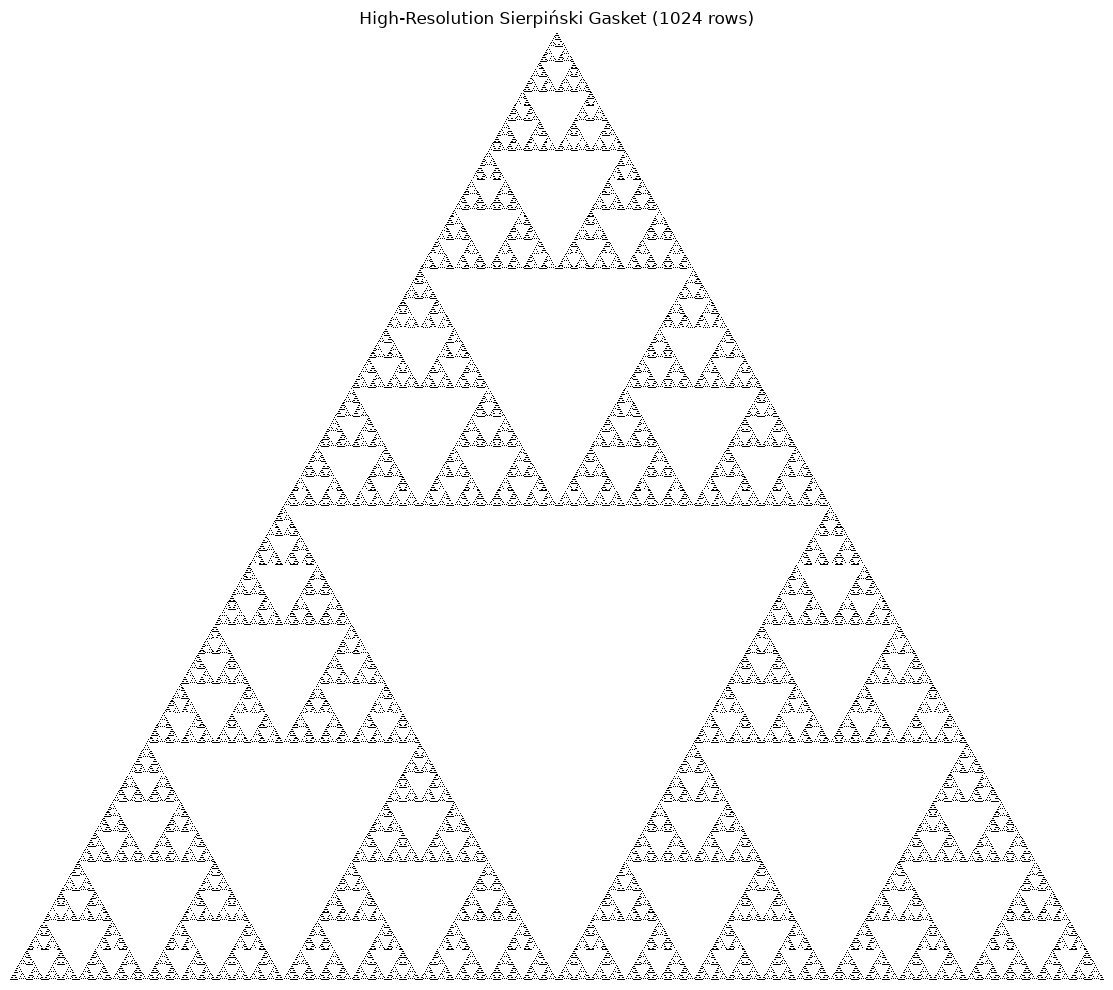

In [9]:
plt.figure(figsize=(12, 10))

plt.imshow(
    centred_high_res.cpu().numpy(),
    cmap="binary",
    interpolation="nearest",
    aspect=3 ** 0.5
)

plt.title(
    f"High-Resolution Sierpiński Gasket "
    f"({high_resolution_size} rows)"
)

plt.axis("off")
plt.tight_layout()
plt.show()